In [1]:
from RNN_Sequences.chicago_transit_data import load_ridership_data
from data_loaders.TimeSeriesDataset import TimeSeriesDataset
from datetime import timedelta
from matplotlib import pyplot as plt
from models.rnn_models import SimpleRnnModel
from torch.utils.data import DataLoader
import pandas as pd
import torch
import torchmetrics

data_scale = 1e6

df_original = load_ridership_data()
df = df_original[["rail"]] / data_scale
df["next_day_type"] = df_original["day_type"].shift(-1)
df = pd.get_dummies(df, dtype=float)
print("Min: ", df.index.min())
print("Max: ", df.index.max())
df


Min:  2001-01-01 00:00:00
Max:  2026-02-28 00:00:00


,rail,next_day_type_A,next_day_type_U,next_day_type_W
date,,,,
2001-01-01,0.126455,0.0,0.0,1.0
2001-01-02,0.501952,0.0,0.0,1.0
2001-01-03,0.536432,0.0,0.0,1.0
2001-01-04,0.550011,0.0,0.0,1.0
2001-01-05,0.557917,1.0,0.0,0.0
...,...,...,...,...
2026-02-24,0.416203,0.0,0.0,1.0
2026-02-25,0.425585,0.0,0.0,1.0
2026-02-26,0.421868,0.0,0.0,1.0


In [2]:
start_date = df.index.min()
valid_start_date = df.index[int(len(df) * 0.6)]
test_start_date = df.index[int(len(df) * 0.8)]

print(start_date, valid_start_date, test_start_date)

2001-01-01 00:00:00 2016-02-06 00:00:00 2021-02-17 00:00:00


In [3]:
window_length = 56

rail_train = torch.FloatTensor(df[start_date:(valid_start_date - timedelta(days=1))].values)
rail_valid = torch.FloatTensor(df[valid_start_date:(test_start_date + timedelta(days=1))].values)
rail_test = torch.FloatTensor(df[test_start_date:].values)

target_slice = slice(0, 1)
train_set = TimeSeriesDataset(rail_train, window_length, target_data_slice=target_slice)
train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
valid_set = TimeSeriesDataset(rail_valid, window_length, target_data_slice=target_slice)
valid_loader = DataLoader(valid_set, batch_size=32)
test_set = TimeSeriesDataset(rail_test, window_length, target_data_slice=target_slice)
test_loader = DataLoader(test_set, batch_size=32)

In [4]:
from model_runner.ModelRunner import ModelRunner
from torch import nn

torch.manual_seed(42)
model = SimpleRnnModel(input_size=4, hidden_size=128, output_size=1)
loss_fn = nn.HuberLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.05, momentum=0.90)
metric = torchmetrics.MeanSquaredLogError()

runner = ModelRunner(model, metric, optimizer, loss_fn)
runner.train_model(train_loader, valid_loader, n_epochs=50, patience=75)

test_result = runner.test_model(test_loader) * 1e6
print(test_result)

Epoch:1 / 50, train loss: 0.0065, train metric: 0.0060, valid metric: 0.0123 (best),  in 3.8s
Epoch:2 / 50, train loss: 0.0013, train metric: 0.0011, valid metric: 0.0046,  in 3.7s
Epoch:3 / 50, train loss: 0.0009, train metric: 0.0008, valid metric: 0.0043,  in 3.4s
Epoch:4 / 50, train loss: 0.0009, train metric: 0.0008, valid metric: 0.0045,  in 3.4s
Epoch:5 / 50, train loss: 0.0009, train metric: 0.0008, valid metric: 0.0043,  in 3.5s
Epoch:6 / 50, train loss: 0.0009, train metric: 0.0008, valid metric: 0.0042,  in 3.3s
Epoch:7 / 50, train loss: 0.0009, train metric: 0.0008, valid metric: 0.0042,  in 3.5s
Epoch:8 / 50, train loss: 0.0009, train metric: 0.0008, valid metric: 0.0041,  in 3.4s
Epoch:9 / 50, train loss: 0.0009, train metric: 0.0008, valid metric: 0.0039,  in 3.4s
Epoch:10 / 50, train loss: 0.0009, train metric: 0.0008, valid metric: 0.0041,  in 3.3s
Epoch:11 / 50, train loss: 0.0009, train metric: 0.0008, valid metric: 0.0041,  in 3.5s
Epoch:12 / 50, train loss: 0.0009,

In [5]:
# Note that in order to make predictions, we must have the past window_length days of data.
test_predictions = runner.run_model(test_loader).cpu()
df_test_predictions = pd.DataFrame(test_predictions)
df_test_predictions = df_test_predictions * data_scale
df_test_predictions.columns = ["predicted_rail"]

start_row_num = df_original.index.get_loc(test_start_date)
predictions_index = df_original.index[start_row_num:start_row_num + len(df_test_predictions)]
df_test_predictions.index = predictions_index
df_test_predictions

,predicted_rail
date,
2021-02-17,497399.562500
2021-02-18,502729.468750
2021-02-19,498488.312500
2021-02-20,204559.125000
2021-02-21,143783.140625
...,...
2025-12-30,586809.875000
2025-12-31,577734.562500
2026-01-01,591968.812500


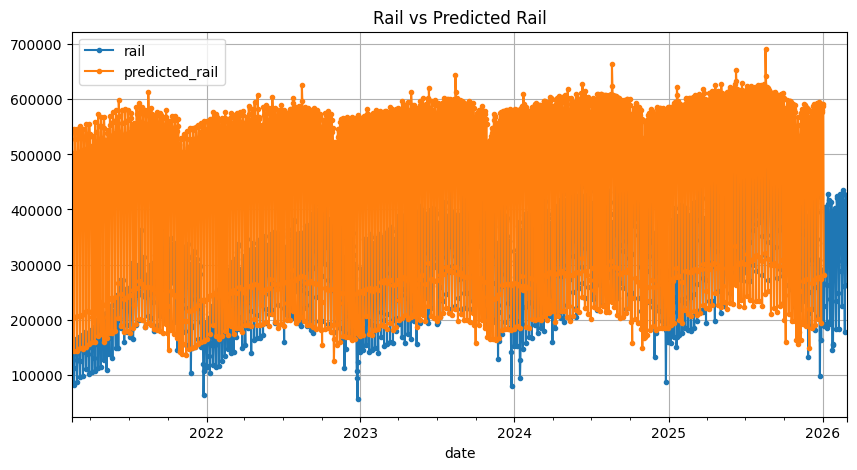

In [6]:
df_test = df_original[test_start_date:][["rail", "bus"]]
df_combined = df_test.join(df_test_predictions, how = "left")

# Plot rail vs predicted_rail
ax1 = df_combined[["rail", "predicted_rail"]].plot(grid=True, marker=".", figsize=(10, 5), title="Rail vs Predicted Rail")
plt.ticklabel_format(style='plain', axis='y')
plt.show()


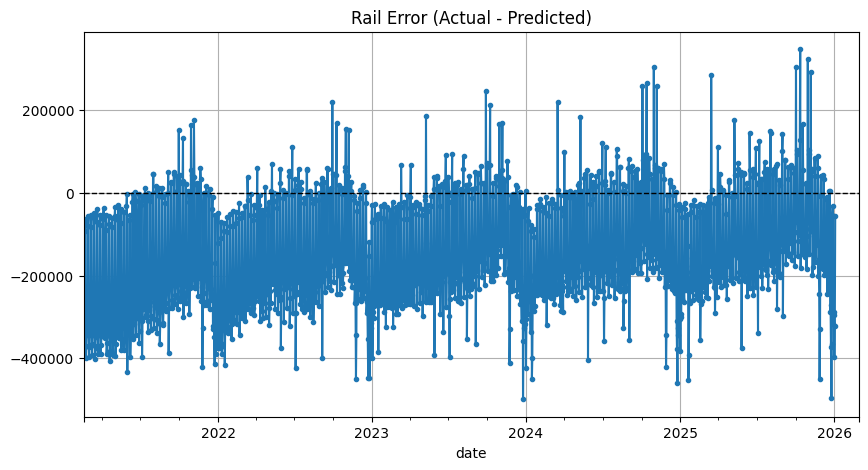

In [7]:
# Plot delta (error) for rail
(df_combined["rail"] - df_combined["predicted_rail"]).plot(grid=True, marker=".", figsize=(10, 5), title="Rail Error (Actual - Predicted)")
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.ticklabel_format(style='plain', axis='y')
plt.show()

